In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

In [2]:
# GPU 활성화 끄기
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [23]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는',celsius_to_faherenheit(input_data))

섭씨온도는?0
화씨온도는 32.0


# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)
## 2.1 노이즈가 없는 데이터로 실습

In [24]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [25]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종족변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [29]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종족변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종족변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [35]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
                input_shape = (1,) #입력(독립)변수의 shape
               ))
print(model.summary())

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


- 회귀분석 오차함수 :
   MSE(오차제곱평균),RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [42]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
               # 손실함수           옵티마저이저     평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [43]:
# 학습 전 예측
model.predict(np.array([[0]
                       [0]]))

1/1 [==============================] - 0s 63ms/step


array([[0.]], dtype=float32)

In [44]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 2(기울기), bias에 b이 있음
# from tensorflow.keras,models import save_model
# save_model(model, 'model/before_learning.h5')

In [45]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                # 독립변수          타겟변수(종속)   학습횟수    학습시출력여부

Epoch 1/1000
4/4 - 1s - loss: 0.4911 - mae: 0.6699 - 570ms/epoch - 142ms/step
Epoch 2/1000
4/4 - 0s - loss: 0.4761 - mae: 0.6592 - 11ms/epoch - 3ms/step
Epoch 3/1000
4/4 - 0s - loss: 0.4639 - mae: 0.6504 - 11ms/epoch - 3ms/step
Epoch 4/1000
4/4 - 0s - loss: 0.4545 - mae: 0.6437 - 8ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 0.4456 - mae: 0.6370 - 8ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 0.4373 - mae: 0.6309 - 8ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 0.4292 - mae: 0.6247 - 9ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 0.4212 - mae: 0.6186 - 8ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 0.4137 - mae: 0.6129 - 8ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 0.4062 - mae: 0.6072 - 9ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 0.3988 - mae: 0.6014 - 7ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 0.3913 - mae: 0.5954 - 7ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 0.3844 - mae: 0.5900 - 5ms/epoch - 1ms/step
Epoch 14/1000
4/4 - 0s - los

4/4 - 0s - loss: 0.0098 - mae: 0.0828 - 8ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 0.0092 - mae: 0.0805 - 6ms/epoch - 1ms/step
Epoch 112/1000
4/4 - 0s - loss: 0.0086 - mae: 0.0782 - 6ms/epoch - 1ms/step
Epoch 113/1000
4/4 - 0s - loss: 0.0082 - mae: 0.0767 - 7ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 0.0078 - mae: 0.0750 - 6ms/epoch - 1ms/step
Epoch 115/1000
4/4 - 0s - loss: 0.0073 - mae: 0.0730 - 6ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 0.0069 - mae: 0.0712 - 6ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 0.0067 - mae: 0.0700 - 7ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 0.0064 - mae: 0.0689 - 8ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 0.0061 - mae: 0.0678 - 7ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 0.0060 - mae: 0.0671 - 7ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 0.0059 - mae: 0.0662 - 6ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 0.0057 - mae: 0.0656 - 7ms/epoch - 2ms/step
Epoch 123/1000
4/4 - 0s - l

Epoch 216/1000
4/4 - 0s - loss: 1.0539e-06 - mae: 0.0010 - 6ms/epoch - 2ms/step
Epoch 217/1000
4/4 - 0s - loss: 5.3396e-07 - mae: 7.0743e-04 - 6ms/epoch - 2ms/step
Epoch 218/1000
4/4 - 0s - loss: 3.7338e-07 - mae: 6.0072e-04 - 7ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 7.7915e-07 - mae: 8.6542e-04 - 6ms/epoch - 1ms/step
Epoch 220/1000
4/4 - 0s - loss: 4.8517e-07 - mae: 6.8471e-04 - 5ms/epoch - 1ms/step
Epoch 221/1000
4/4 - 0s - loss: 7.4467e-07 - mae: 8.4488e-04 - 5ms/epoch - 1ms/step
Epoch 222/1000
4/4 - 0s - loss: 4.8481e-07 - mae: 6.6933e-04 - 7ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 6.0992e-07 - mae: 7.5350e-04 - 8ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 4.2857e-07 - mae: 6.4057e-04 - 6ms/epoch - 1ms/step
Epoch 225/1000
4/4 - 0s - loss: 7.9164e-07 - mae: 8.6061e-04 - 6ms/epoch - 1ms/step
Epoch 226/1000
4/4 - 0s - loss: 2.1148e-07 - mae: 4.4960e-04 - 6ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 8.4204e-07 - mae: 8.9955e-04 - 6ms/epoch - 2ms/s

Epoch 314/1000
4/4 - 0s - loss: 1.6048e-07 - mae: 3.8778e-04 - 6ms/epoch - 2ms/step
Epoch 315/1000
4/4 - 0s - loss: 4.5613e-07 - mae: 6.5142e-04 - 6ms/epoch - 1ms/step
Epoch 316/1000
4/4 - 0s - loss: 9.3170e-07 - mae: 9.3132e-04 - 5ms/epoch - 1ms/step
Epoch 317/1000
4/4 - 0s - loss: 5.5421e-07 - mae: 7.2089e-04 - 6ms/epoch - 1ms/step
Epoch 318/1000
4/4 - 0s - loss: 3.9288e-07 - mae: 6.1029e-04 - 7ms/epoch - 2ms/step
Epoch 319/1000
4/4 - 0s - loss: 5.2941e-07 - mae: 7.1080e-04 - 6ms/epoch - 1ms/step
Epoch 320/1000
4/4 - 0s - loss: 5.2070e-07 - mae: 7.0758e-04 - 5ms/epoch - 1ms/step
Epoch 321/1000
4/4 - 0s - loss: 9.6703e-07 - mae: 9.5805e-04 - 6ms/epoch - 2ms/step
Epoch 322/1000
4/4 - 0s - loss: 9.3045e-08 - mae: 2.9824e-04 - 6ms/epoch - 2ms/step
Epoch 323/1000
4/4 - 0s - loss: 3.6536e-07 - mae: 5.8275e-04 - 7ms/epoch - 2ms/step
Epoch 324/1000
4/4 - 0s - loss: 2.6032e-07 - mae: 4.5808e-04 - 7ms/epoch - 2ms/step
Epoch 325/1000
4/4 - 0s - loss: 1.7019e-06 - mae: 0.0013 - 6ms/epoch - 1ms/s

Epoch 413/1000
4/4 - 0s - loss: 4.2450e-07 - mae: 6.3739e-04 - 6ms/epoch - 1ms/step
Epoch 414/1000
4/4 - 0s - loss: 4.7048e-07 - mae: 6.5997e-04 - 6ms/epoch - 2ms/step
Epoch 415/1000
4/4 - 0s - loss: 8.4144e-07 - mae: 9.0005e-04 - 6ms/epoch - 2ms/step
Epoch 416/1000
4/4 - 0s - loss: 6.3308e-07 - mae: 7.7295e-04 - 6ms/epoch - 2ms/step
Epoch 417/1000
4/4 - 0s - loss: 7.1737e-07 - mae: 8.2393e-04 - 8ms/epoch - 2ms/step
Epoch 418/1000
4/4 - 0s - loss: 2.5845e-07 - mae: 4.9840e-04 - 7ms/epoch - 2ms/step
Epoch 419/1000
4/4 - 0s - loss: 2.0397e-07 - mae: 4.2908e-04 - 7ms/epoch - 2ms/step
Epoch 420/1000
4/4 - 0s - loss: 8.9292e-07 - mae: 9.1595e-04 - 6ms/epoch - 1ms/step
Epoch 421/1000
4/4 - 0s - loss: 5.6824e-07 - mae: 7.3273e-04 - 7ms/epoch - 2ms/step
Epoch 422/1000
4/4 - 0s - loss: 7.0624e-07 - mae: 8.1985e-04 - 6ms/epoch - 1ms/step
Epoch 423/1000
4/4 - 0s - loss: 3.5157e-07 - mae: 5.8100e-04 - 6ms/epoch - 1ms/step
Epoch 424/1000
4/4 - 0s - loss: 1.0118e-06 - mae: 9.8703e-04 - 6ms/epoch - 2

4/4 - 0s - loss: 5.5387e-07 - mae: 7.1927e-04 - 6ms/epoch - 1ms/step
Epoch 512/1000
4/4 - 0s - loss: 1.2042e-06 - mae: 0.0011 - 6ms/epoch - 1ms/step
Epoch 513/1000
4/4 - 0s - loss: 1.3822e-07 - mae: 3.6453e-04 - 8ms/epoch - 2ms/step
Epoch 514/1000
4/4 - 0s - loss: 2.3291e-07 - mae: 4.6854e-04 - 6ms/epoch - 1ms/step
Epoch 515/1000
4/4 - 0s - loss: 1.0864e-06 - mae: 0.0010 - 6ms/epoch - 1ms/step
Epoch 516/1000
4/4 - 0s - loss: 2.8459e-07 - mae: 5.1949e-04 - 6ms/epoch - 1ms/step
Epoch 517/1000
4/4 - 0s - loss: 7.1749e-07 - mae: 8.3129e-04 - 9ms/epoch - 2ms/step
Epoch 518/1000
4/4 - 0s - loss: 8.4994e-07 - mae: 8.9524e-04 - 7ms/epoch - 2ms/step
Epoch 519/1000
4/4 - 0s - loss: 7.6496e-07 - mae: 8.2719e-04 - 7ms/epoch - 2ms/step
Epoch 520/1000
4/4 - 0s - loss: 1.8372e-07 - mae: 4.1716e-04 - 5ms/epoch - 1ms/step
Epoch 521/1000
4/4 - 0s - loss: 5.7964e-07 - mae: 7.4028e-04 - 6ms/epoch - 1ms/step
Epoch 522/1000
4/4 - 0s - loss: 1.0264e-06 - mae: 9.7614e-04 - 5ms/epoch - 1ms/step
Epoch 523/1000


Epoch 610/1000
4/4 - 0s - loss: 7.6711e-07 - mae: 8.4966e-04 - 7ms/epoch - 2ms/step
Epoch 611/1000
4/4 - 0s - loss: 3.2852e-07 - mae: 5.6154e-04 - 7ms/epoch - 2ms/step
Epoch 612/1000
4/4 - 0s - loss: 9.2706e-07 - mae: 9.4454e-04 - 7ms/epoch - 2ms/step
Epoch 613/1000
4/4 - 0s - loss: 6.7222e-07 - mae: 8.0014e-04 - 7ms/epoch - 2ms/step
Epoch 614/1000
4/4 - 0s - loss: 3.8643e-07 - mae: 6.0572e-04 - 8ms/epoch - 2ms/step
Epoch 615/1000
4/4 - 0s - loss: 8.6610e-07 - mae: 9.0462e-04 - 8ms/epoch - 2ms/step
Epoch 616/1000
4/4 - 0s - loss: 3.7404e-07 - mae: 5.9809e-04 - 8ms/epoch - 2ms/step
Epoch 617/1000
4/4 - 0s - loss: 4.7447e-07 - mae: 6.7359e-04 - 8ms/epoch - 2ms/step
Epoch 618/1000
4/4 - 0s - loss: 7.6278e-07 - mae: 8.5756e-04 - 8ms/epoch - 2ms/step
Epoch 619/1000
4/4 - 0s - loss: 6.5911e-07 - mae: 7.9358e-04 - 6ms/epoch - 2ms/step
Epoch 620/1000
4/4 - 0s - loss: 3.6295e-07 - mae: 5.8764e-04 - 7ms/epoch - 2ms/step
Epoch 621/1000
4/4 - 0s - loss: 3.6554e-07 - mae: 5.8464e-04 - 7ms/epoch - 2

Epoch 708/1000
4/4 - 0s - loss: 8.8623e-07 - mae: 9.2100e-04 - 7ms/epoch - 2ms/step
Epoch 709/1000
4/4 - 0s - loss: 3.5318e-07 - mae: 5.8118e-04 - 7ms/epoch - 2ms/step
Epoch 710/1000
4/4 - 0s - loss: 4.4395e-07 - mae: 6.4776e-04 - 6ms/epoch - 2ms/step
Epoch 711/1000
4/4 - 0s - loss: 5.3813e-07 - mae: 7.2047e-04 - 6ms/epoch - 1ms/step
Epoch 712/1000
4/4 - 0s - loss: 2.9980e-07 - mae: 5.1761e-04 - 6ms/epoch - 1ms/step
Epoch 713/1000
4/4 - 0s - loss: 4.8370e-07 - mae: 6.4741e-04 - 6ms/epoch - 1ms/step
Epoch 714/1000
4/4 - 0s - loss: 1.0803e-06 - mae: 0.0010 - 6ms/epoch - 1ms/step
Epoch 715/1000
4/4 - 0s - loss: 3.1508e-07 - mae: 5.4945e-04 - 5ms/epoch - 1ms/step
Epoch 716/1000
4/4 - 0s - loss: 6.0552e-07 - mae: 7.6377e-04 - 5ms/epoch - 1ms/step
Epoch 717/1000
4/4 - 0s - loss: 8.0585e-07 - mae: 8.7913e-04 - 6ms/epoch - 2ms/step
Epoch 718/1000
4/4 - 0s - loss: 5.2835e-07 - mae: 7.1145e-04 - 6ms/epoch - 1ms/step
Epoch 719/1000
4/4 - 0s - loss: 5.8791e-07 - mae: 7.4961e-04 - 7ms/epoch - 2ms/s

Epoch 806/1000
4/4 - 0s - loss: 2.1839e-07 - mae: 4.5474e-04 - 5ms/epoch - 1ms/step
Epoch 807/1000
4/4 - 0s - loss: 1.0196e-06 - mae: 9.8641e-04 - 6ms/epoch - 2ms/step
Epoch 808/1000
4/4 - 0s - loss: 6.5066e-07 - mae: 7.6920e-04 - 6ms/epoch - 2ms/step
Epoch 809/1000
4/4 - 0s - loss: 3.1258e-07 - mae: 5.4733e-04 - 6ms/epoch - 2ms/step
Epoch 810/1000
4/4 - 0s - loss: 5.7972e-07 - mae: 7.4290e-04 - 5ms/epoch - 1ms/step
Epoch 811/1000
4/4 - 0s - loss: 7.4054e-07 - mae: 8.4230e-04 - 6ms/epoch - 2ms/step
Epoch 812/1000
4/4 - 0s - loss: 2.4646e-07 - mae: 4.8763e-04 - 6ms/epoch - 1ms/step
Epoch 813/1000
4/4 - 0s - loss: 1.2194e-06 - mae: 0.0011 - 5ms/epoch - 1ms/step
Epoch 814/1000
4/4 - 0s - loss: 1.9250e-07 - mae: 4.2716e-04 - 7ms/epoch - 2ms/step
Epoch 815/1000
4/4 - 0s - loss: 3.2929e-07 - mae: 5.5662e-04 - 6ms/epoch - 1ms/step
Epoch 816/1000
4/4 - 0s - loss: 1.3323e-06 - mae: 0.0011 - 7ms/epoch - 2ms/step
Epoch 817/1000
4/4 - 0s - loss: 2.8163e-07 - mae: 5.0308e-04 - 7ms/epoch - 2ms/step


Epoch 905/1000
4/4 - 0s - loss: 2.8479e-07 - mae: 5.1758e-04 - 5ms/epoch - 1ms/step
Epoch 906/1000
4/4 - 0s - loss: 1.4848e-06 - mae: 0.0012 - 8ms/epoch - 2ms/step
Epoch 907/1000
4/4 - 0s - loss: 3.0081e-07 - mae: 5.2116e-04 - 6ms/epoch - 1ms/step
Epoch 908/1000
4/4 - 0s - loss: 2.3082e-07 - mae: 4.5890e-04 - 5ms/epoch - 1ms/step
Epoch 909/1000
4/4 - 0s - loss: 8.5442e-07 - mae: 8.9842e-04 - 5ms/epoch - 1ms/step
Epoch 910/1000
4/4 - 0s - loss: 9.7520e-07 - mae: 9.5164e-04 - 6ms/epoch - 1ms/step
Epoch 911/1000
4/4 - 0s - loss: 1.7413e-07 - mae: 4.0933e-04 - 6ms/epoch - 2ms/step
Epoch 912/1000
4/4 - 0s - loss: 2.5317e-07 - mae: 4.8052e-04 - 5ms/epoch - 1ms/step
Epoch 913/1000
4/4 - 0s - loss: 1.3462e-06 - mae: 0.0011 - 6ms/epoch - 2ms/step
Epoch 914/1000
4/4 - 0s - loss: 4.7159e-07 - mae: 6.4282e-04 - 6ms/epoch - 1ms/step
Epoch 915/1000
4/4 - 0s - loss: 2.5338e-07 - mae: 4.8760e-04 - 6ms/epoch - 1ms/step
Epoch 916/1000
4/4 - 0s - loss: 3.4403e-07 - mae: 5.6290e-04 - 6ms/epoch - 1ms/step


In [48]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

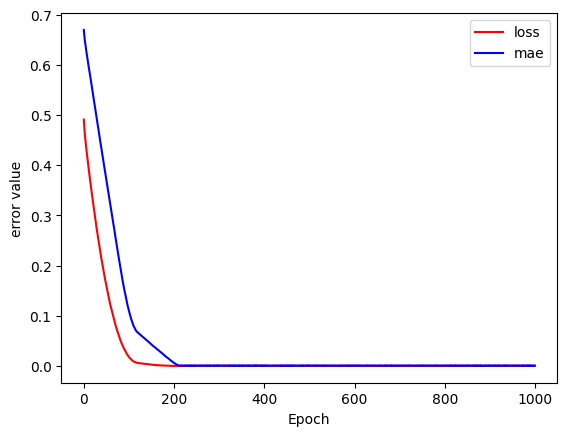

In [50]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [52]:
# 모델 사용
model.predict(np.array([[0],
                       [0.01],
                       [0.02]]))

1/1 [==============================] - 0s 65ms/step


array([[0.3202992 ],
       [0.33830482],
       [0.35631043]], dtype=float32)

In [53]:
model.save('model/after_learning.h5')